# Logistische Regression Modelling


## Setup

In [1]:
# Magic Codes 
%load_ext autoreload
%autoreload 2

# IMPORTS
from us_used_vehicle_resales.features import engineer_features
from us_used_vehicle_resales.cleaning import clean_data
import us_used_vehicle_resales as wg  
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, HTML
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from us_used_vehicle_resales.config_features_catalog import features_catalog
from us_used_vehicle_resales.config_models_catalog import models_catalog
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import fbeta_score
from sklearn.model_selection import GridSearchCV

from us_used_vehicle_resales import models
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score


from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, recall_score, precision_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import warnings

# SETTINGS
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Global Notebook Style
display(HTML("<style>table { margin-left: 0 !important; }</style>"))

# Global Pandas Options
pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.memory_usage', 'deep')

# CONSTANTS
TARGET = 'IsBadBuy'
tracker = wg.ModelTracker(csv_path='../data/04_models/model_results_tracking.csv')

# LOADING DATA
wg.print_header('Modelling Started')
X_train_all = pd.read_parquet('../data/03_processed/X_train_final.parquet')
y_train_all = pd.read_parquet('../data/03_processed/y_train.parquet').iloc[:, 0]
print(f"🚀 Daten erfolgreich geladen.")
print(f"Features: {X_train_all.shape[0]} Zeilen | {X_train_all.shape[1]} Spalten")
print(f"Target:   '{y_train_all.name}' (BadBuy-Rate: {y_train_all.mean():.2%})")
wg.print_footer()


# VALIDATION SPLIT
X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, y_train_all, test_size=0.2, random_state=42, stratify=y_train_all
)
wg.print_header('Validation Split')
print(f"🚀 Daten erfolgreich gesplittet.")
print(f"Train: {X_train.shape[0]} | Validation: {X_val.shape[0]}")
wg.print_footer()





~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
MODELLING STARTED
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 Daten erfolgreich geladen.
Features: 52496 Zeilen | 41 Spalten
Target:   'IsBadBuy' (BadBuy-Rate: 12.35%)
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~





~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
VALIDATION SPLIT
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
🚀 Daten erfolgreich gesplittet.
Train: 41996 | Validation: 10500
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~




# Ranking

In [5]:
# Hol dir alle Ergebnisse als DataFrame
df_results = tracker.get_results()
top_models = df_results.sort_values(by='F1-Score', ascending=False).head(33)
display(top_models)


,Run_ID,Timestamp,Model,Features Name,Features Count,F1-Score,Recall,Precision,ROC-AUC,Description,Model_File,Is_Best
438,438,2026-04-02 08:56:26,reconstructed_402_lasso_thresh_0.72,NaN,NaN,0.4064,0.3439,0.4967,0.0000,NaN,export/438_reconstructed_402_lasso_thresh_0.72...,True
433,433,2026-04-01 21:53:51,reconstructed_402_lasso_thresh_0.66,NaN,NaN,0.4014,0.3863,0.4178,0.0000,NaN,export/433_reconstructed_402_lasso_thresh_0.66...,True
431,431,2026-04-01 21:36:03,logreg_lasso_grid_best,NaN,NaN,0.3814,0.6284,0.2738,0.0000,"🏆 Gewinner: {'model__C': 0.1, 'model__max_iter...",export/431_logreg_lasso_grid_best.joblib,False
429,429,2026-04-01 20:59:59,logreg_lasso_grid_best,NaN,NaN,0.3814,0.6284,0.2738,0.0000,"🏆 Gewinner: {'model__C': 0.1, 'model__solver':...",export/429_logreg_lasso_grid_best.joblib,True
402,402,2026-04-01 11:16:09,log_reg_lasso_all_in_with_noise,NaN,NaN,0.3801,0.6245,0.2732,0.0000,Auto-Run: log_reg_lasso mit all_in_with_noise ...,export/402_log_reg_lasso_all_in_with_noise.joblib,True
406,406,2026-04-01 11:18:09,hist_boost_aggressive_all_in_with_noise,NaN,NaN,0.3756,0.6130,0.2708,0.0000,Auto-Run: hist_boost_aggressive mit all_in_wit...,export/406_hist_boost_aggressive_all_in_with_n...,False
45,45,2026-04-01 08:53:50,hist_boost_all_in_with_noise,all_in_with_noise,28.0000,0.3726,0.6029,0.2696,0.0000,Auto-Run: hist_boost mit all_in_with_noise Fea...,export/045_hist_boost_all_in_with_noise.joblib,NaN
427,427,2026-04-01 20:43:35,logreg_lasso_full_buffet,NaN,NaN,0.3725,0.6376,0.2631,0.0000,NaN,export/427_logreg_lasso_full_buffet.joblib,False
419,419,2026-04-01 20:13:18,logreg_lasso_full_buffet,NaN,NaN,0.3725,0.6376,0.2631,0.0000,NaN,export/419_logreg_lasso_full_buffet.joblib,False
426,426,2026-04-01 20:40:42,logreg_lasso_full_buffet,NaN,NaN,0.3725,0.6376,0.2631,0.0000,NaN,export/426_logreg_lasso_full_buffet.joblib,False


# Run Initial Systematic Benchmark


### Lasso
* Unwichtige Features werden komplett auf **null gesetzt**
### Ridge
* Einfluss der Features wird **quadratisch gewichtet**
### Elastic
* Mischform aus Lasso und Ridge, l1_ratio = 0.5 → 50% Lasso, 50% Ridge

### Sampling
* Bei BadBuys-Unterzahl bietet sich Oversampling an.
* Im ersten Schritt automatisch mit **class_weight='balanced'**, später eventuel auch **SMOTE** mit ImBPipeline. 

### Scaling und Encoding
* Über den **ColumnTransformer** können **Numerical** und **Categorical** Features separat behandelt werden
* Numerische Features werden mit dem **StandardScaler** zur standardisieren
* Kategorische Features werden mit dem **OneHotEncoder** in Zahlen/Spalten transformiert

#### Modelle
* **log_reg_ridge** (l1_ratio=0, C=0.1, solver='saga', class_weight='balanced')
* **log_reg_lasso** (l1_ratio=1, C=0.1, solver='saga', class_weight='balanced')
* **log_reg_elastic** (l1_ratio=0.5, C=0.1, solver='saga', class_weight='balanced')

#### Pipe
* **ColumnTransformer:** `StandardScaler` für numerische Daten, `OneHotEncoder` (handle_unknown='ignore') für kategorische Daten.

#### Erkenntnisse
* **Lasso ist der Champion:** Das Modell `log_reg_lasso` mit dem Feature-Set `all_in_with_noise` liefert mit einem **F1-Score von 0.38** und einem **Recall von 0.62** das bisher stärkste Gesamtergebnis der LogReg-Reihe.
* **Feature-Abhängigkeit:** Die Performance bricht massiv ein (F1 von 0.38 auf 0.29), wenn nur numerische Daten oder das `baseline_classic` Set verwendet werden. Die kategorialen Informationen ("Noise" und "Cats") sind essenziell.
* **Hoher Recall-Fokus:** Die Logistische Regression zeigt eine konsistente Stärke darin, über **60% der Bad Buys** zu identifizieren (Recall), erkauft dies jedoch mit einer niedrigen Precision (~0.27).




### 🔍 Was uns das für die "Justierung" sagt:

1.  **Lasso wirkt:** Dass `log_reg_lasso` (F1 0.38) besser performt als `log_reg_balanced` (F1 0.36), zeigt, dass das Modell davon profitiert, unwichtige Features eiskalt auszusortieren.
2.  **Potential bei Champion_v1:** Überraschenderweise performt dein manuell ausgewähltes `champion_v1` Set schlechter als `all_in_with_noise`. Das bedeutet, in den "Noise"-Daten verstecken sich Signale, die wir bisher unterschätzt haben.
3.  **Nächster Hebel:** Da der Recall schon super ist (62%), müssen wir jetzt an der **Precision** arbeiten.



In [3]:
#SYSTEMATIC BENCHMARK


#----------------------------------------
# PIPELINE
#----------------------------------------
#----------------------------------------

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_pipeline(model_obj, feature_list, X_train):
    """
    Erstellt eine Scikit-Learn Pipeline basierend auf einer Feature-Liste.
    Trennt automatisch numerische und kategorische Spalten.
    """
    # 1. Spalten identifizieren, die TATSÄCHLICH in feature_list sind
    # (Verhindert Fehler, falls die Liste Spalten enthält, die nicht im DF sind)
    numeric_features = [col for col in feature_list if col in X_train.select_dtypes(include=['int64', 'float64']).columns]
    categorical_features = [col for col in feature_list if col in X_train.select_dtypes(include=['object', 'category']).columns]

    # 2. Transformer definieren
    numeric_transformer = StandardScaler()
    categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

    # 3. ColumnTransformer zusammenbauen
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, numeric_features),
            ('cat', categorical_transformer, categorical_features)
        ]
    )

    # 4. Finale Pipeline mit dem übergebenen Modell-Objekt
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_obj)
    ])
    
#----------------------------------------
#----------------------------------------



#----------------------------------------
# LOOP
#----------------------------------------
#----------------------------------------

def start_loop(features_cat, model_cat):

    wg.print_header("STARTING SYSTEMATIC BENCHMARK")
    
    # Wir loopen durch alle Feature-Sets im Katalog
    for f_name, f_list in features_cat.items():
        
        wg.print_title(f"Testing Feature-Set: {f_name}")
        
        # Wir loopen durch alle Modelle im Katalog
        for m_name, m_obj in model_cat.items():
            
            run_name = f"{m_name}_{f_name}"
            
            # 1. Pipeline erstellen
            # Wichtig: Die Pipeline muss wissen, welche Spalten sie verarbeiten soll!
            pipeline = build_pipeline(m_obj, f_list, X_train) 
            
            # 2. Modell trainieren
            # Wir füttern nur die Spalten aus der aktuellen Liste
            pipeline.fit(X_train, y_train)
            
            # 3. Vorhersage auf dem Validation-Set
            y_val_pred = pipeline.predict(X_val)
            
            # 4. In den Tracker schreiben
            tracker.add_entry(
                model_name=run_name,
                model_obj=pipeline,
                features_name=f_name,
                features_list=f_list,
                y_true=y_val,
                y_pred=y_val_pred,
                description=f"Auto-Run: {m_name} mit {f_name} Features"
            )
    
    # 5. Speichern der CSV am Ende des gesamten Durchlaufs
    #tracker.save_to_csv()
    
    wg.print_header("BENCHMARK FINISHED")
    
#----------------------------------------
#----------------------------------------






#----------------------------------------
# CATALOGES
#----------------------------------------
#----------------------------------------

from us_used_vehicle_resales.config_features_catalog import features_catalog as features_catalog

from us_used_vehicle_resales.config_models_catalog import models_catalog as log_reg_models_catalog

models_catalog = log_reg_models_catalog
#----------------------------------------
#----------------------------------------




In [ ]:
# ACTION Inital

start_loop(features_catalog, models_catalog)

tracker.get_results().sort_values(by='F1-Score', ascending=False)

# First Pick



**Die Spitzenreiter: "All In With Noise" (F1 ~ 0.38)**

Ganz oben (ID 402, 401, 43) sehen wir Werte von **0.36 bis 0.38.**

Das Muster: Hier wurde das Feature-Set massiv vergrößert. Trotz des Namens "with noise" scheint die Kombination aus allen verfügbaren Infos plus Lasso-Regularisierung (log_reg_lasso_all_in) die beste Balance gefunden zu haben.

Der entscheidende Faktor: Die Precision ist hier auf 0.27 geklettert, während der Recall stabil bei 0.62 blieb.

* log_reg_balanced + cats_strong

* log_reg_lasso + all_in_with_noise


In [ ]:
from us_used_vehicle_resales.config_features_catalog import features_catalog
from us_used_vehicle_resales.config_models_catalog import log_reg_models_catalog_01

features = features_catalog['log_reg_set_01']

def build_logreg_pipeline(model_obj, feature_list, X_train):
    # 1. Spalten sortieren
    # Welche sollen geloggt werden? (KM, Kosten, Garantie)
    log_cols = [c for c in ['VehOdo', 'VehBCost', 'WarrantyCost'] if c in feature_list]
    
    # Welche sind normal numerisch?
    num_cols = [c for c in feature_list if c in X_train.select_dtypes(include=[np.number]).columns and c not in log_cols]
    
    # Welche sind kategorial?
    cat_cols = [c for c in feature_list if c in X_train.select_dtypes(include=['object', 'category']).columns]

    # 2. Transformer Ketten
    # Kette für Log-Features: Erst Log(x+1), dann Skalieren
    log_transformer = Pipeline([
        ('log', FunctionTransformer(np.log1p)),
        ('scaler', StandardScaler())
    ])

    # 3. ColumnTransformer zusammenbauen
    preprocessor = ColumnTransformer(transformers=[
        ('log_nums', log_transformer, log_cols),
        ('std_nums', StandardScaler(), num_cols),
        ('cats', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

    return Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model_obj)
    ])


from sklearn.model_selection import cross_validate, StratifiedKFold

# Wir definieren, wie wir splitten wollen (5-fach, stabil durch 'Stratified')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"🚀 Starte Deep-Dive mit 5-facher Cross-Validation...")

for m_name, m_obj in log_reg_models_catalog_01.items():
    # 1. Pipeline bauen
    pipeline = build_logreg_pipeline(m_obj, features, X_train)
    
    # 2. Cross-Validation ausführen (auf dem GANZEN X_train!)
    # Wir messen F1, Recall und Precision gleichzeitig
    cv_results = cross_validate(
        pipeline, X_train, y_train, 
        cv=skf, 
        scoring=['f1', 'recall', 'precision'],
        n_jobs=-1 # Nutzt alle CPU-Kerne -> spart Zeit!
    )
    
    # 3. Ergebnisse mitteln
    f1_mean = np.mean(cv_results['test_f1'])
    f1_std  = np.std(cv_results['test_f1']) # Die "Schwankung"
    
    print(f"📊 {m_name}: Mean F1 = {f1_mean:.4f} (+/- {f1_std:.4f})")
    
    # 4. Finales Training für den Tracker (auf allen Daten)
    pipeline.fit(X_train, y_train)
    y_val_pred = pipeline.predict(X_val)
    
    tracker.add_entry(
        model_name=f"{m_name}_CV",
        model_obj=pipeline,
        features_name="log_reg_set_01",
        features_list=features,
        y_true=y_val,
        y_pred=y_val_pred,
        description=f"CV Mean F1: {f1_mean:.4f}"
    )

display(tracker.get_results().tail(len(log_reg_models_catalog_01)))




In [22]:
df_results = tracker.get_results()
df_logreg = df_results[df_results['Model'].str.contains('logreg|log_reg', case=False, na=False)]
df_top_logreg = df_logreg.sort_values(by='F1-Score', ascending=False).head(33)
df_top_logreg

,Run_ID,Timestamp,Model,Features Name,Features Count,F1-Score,Recall,Precision,ROC-AUC,Description,Model_File,Is_Best
402,402,2026-04-01 11:16:09,log_reg_lasso_all_in_with_noise,NaN,NaN,0.3801,0.6245,0.2732,0.0000,Auto-Run: log_reg_lasso mit all_in_with_noise ...,export/402_log_reg_lasso_all_in_with_noise.joblib,True
401,401,2026-04-01 11:02:30,log_reg_balanced_all_in_with_noise,NaN,NaN,0.3695,0.6130,0.2645,0.0000,Auto-Run: log_reg_balanced mit all_in_with_noi...,export/401_log_reg_balanced_all_in_with_noise....,False
43,43,2026-04-01 08:52:46,log_reg_all_in_with_noise,all_in_with_noise,28.0000,0.3676,0.6083,0.2634,0.0000,Auto-Run: log_reg mit all_in_with_noise Features,export/043_log_reg_all_in_with_noise.joblib,NaN
150,150,2026-04-01 09:16:11,log_reg_lasso_cats_strong,NaN,NaN,0.3468,0.5343,0.2568,0.0000,Auto-Run: log_reg_lasso mit cats_strong Features,export/150_log_reg_lasso_cats_strong.joblib,False
196,196,2026-04-01 09:21:01,log_reg_lasso_cats_strong,NaN,NaN,0.3468,0.5343,0.2568,0.0000,Auto-Run: log_reg_lasso mit cats_strong Features,export/196_log_reg_lasso_cats_strong.joblib,False
281,281,2026-04-01 09:42:05,log_reg_lasso_cats_strong,NaN,NaN,0.3468,0.5343,0.2568,0.0000,Auto-Run: log_reg_lasso mit cats_strong Features,export/281_log_reg_lasso_cats_strong.joblib,False
390,390,2026-04-01 10:08:18,log_reg_lasso_high_impact_categories,NaN,NaN,0.3468,0.5343,0.2568,0.0000,Auto-Run: log_reg_lasso mit high_impact_catego...,export/390_log_reg_lasso_high_impact_categorie...,False
360,360,2026-04-01 10:04:13,log_reg_lasso_cats_strong,NaN,NaN,0.3468,0.5343,0.2568,0.0000,Auto-Run: log_reg_lasso mit cats_strong Features,export/360_log_reg_lasso_cats_strong.joblib,False
311,311,2026-04-01 09:46:29,log_reg_lasso_high_impact_categories,NaN,NaN,0.3468,0.5343,0.2568,0.0000,Auto-Run: log_reg_lasso mit high_impact_catego...,export/311_log_reg_lasso_high_impact_categorie...,False
37,37,2026-04-01 08:50:22,log_reg_high_impact_categories,high_impact_categories,7.0000,0.3404,0.5536,0.2458,0.0000,Auto-Run: log_reg mit high_impact_categories F...,export/037_log_reg_high_impact_categories.joblib,NaN


# Next Adjustments
	

* Angepasster Lasso

* Angepasster Balanced

In [ ]:


#X_train, X_val, y_train, y_val 

# ==========================================
# 1. TURBO-FEATURES DEFINIEREN
# ==========================================
# Wir fügen die Interaktionen direkt in deine X_train/X_test ein
for df in [X_train, X_val]:
    # Kombination aus Alter und Nutzung (Verschleiß-Index)
    df['feat_wear_tear'] = df['VehicleAge'] * (df['VehOdo'] / 10000)
    # Preis-Leistungs-Anomalie (Was kostet das Jahr?)
    df['feat_price_age_ratio'] = df['VehBCost'] / (df['VehicleAge'] + 1)

# Das "Turbo-Set" definieren (Alles + die neuen 2)
set_turbo = (features_catalog['all_in_with_noise'] + 
             ['feat_wear_tear', 'feat_price_age_ratio'])

# ==========================================
# 2. DIE ULTIMATIVE TRAININGS-FUNKTION (PCA + LASSO)
# ==========================================
def train_advanced_logreg(X_data, y_data, use_pca=False, penalty='l1'):
    """
    Erstellt eine Pipeline mit optionaler PCA und Lasso/Ridge.
    """
    num_cols = X_data.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = X_data.select_dtypes(include=['object', 'category']).columns.tolist()
    
    # Preprocessor (Wichtig: sparse=False für PCA!)
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])
    
    steps = [('pre', preprocessor)]
    
    # Falls PCA gewünscht, hier einfügen
    if use_pca:
        steps.append(('pca', PCA(n_components=0.95))) # Behalte 95% der Info
        
    # Das Modell (Lasso braucht 'liblinear' oder 'saga')
    steps.append(('model', LogisticRegression(
        penalty=penalty,
        C=0.5,                  # Stärke der Regulierung (kleiner = strenger)
        class_weight='balanced',
        solver='saga',          # Saga kann L1 (Lasso) und ist schnell
        max_iter=5000,
        random_state=42
    )))
    
    pipeline = Pipeline(steps)
    pipeline.fit(X_data, y_data)
    
    # Kleiner Check: Wie viele Features nach OHE?
    if use_pca:
        n_comps = pipeline.named_steps['pca'].n_components_
        print(f"✅ PCA aktiv: Daten von {X_data.shape[1]} auf {n_comps} Komponenten komprimiert.")
    
    return pipeline


# ==========================================
# 3. DIE EXPERIMENTE STARTEN (Mit Tracker)
# ==========================================

# 1. Sicherstellen, dass nur existierende Spalten genutzt werden
set_turbo_cleaned = [f for f in set_turbo if f in X_train.columns]

X_train_final = X_train[set_turbo_cleaned].copy()
X_test_final = X_val[set_turbo_cleaned].copy()

# --- RUN A: LASSO (Scharfschütze) ---
print("\n--- Run A: Lasso (Turbo-Set) ---")
pipe_lasso = train_advanced_logreg(X_train_final, y_train, use_pca=False, penalty='l1')
y_pred_lasso = pipe_lasso.predict(X_test_final)

# ERGEBNIS IM TRACKER SPEICHERN
tracker.log_result("logreg_lasso_turbo_v1", pipe_lasso, X_test_final, y_test)


# --- RUN B: PCA + BALANCED (Brechstange) ---
print("\n--- Run B: PCA + Balanced (Turbo-Set) ---")
pipe_pca = train_advanced_logreg(X_train_final, y_train, use_pca=True, penalty='l2')
y_pred_pca = pipe_pca.predict(X_test_final)

# ERGEBNIS IM TRACKER SPEICHERN
tracker.log_result("logreg_pca_balanced_turbo_v1", pipe_pca, X_test_final, y_test)

# ==========================================
# 4. VERGLEICH ANZEIGEN
# ==========================================
df_results = tracker.get_results()
# Zeige uns nur die neuen Versuche im Vergleich zu den alten Top-Werten
df_results[df_results['model_name'].str.contains('turbo|all_in', case=False)].sort_values('f1_score', ascending=False)





--- Run A: Lasso (Turbo-Set) ---


/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [32]:
target_features = [f for f in features_catalog['all_in'] if f in X_train.columns]
X_train_final = X_train[target_features].copy()
X_val_final = X_val[target_features].copy()

# 2. SPALTEN-LISTEN AUS DEM KATALOG (Nur Namen)
price_cols = [f for f in features_catalog['price'] if f in X_train_final.columns]
num_cols   = [f for f in features_catalog['numeric'] if f in X_train_final.columns]
cat_cols   = [f for f in features_catalog['cats_strong'] if f in X_train_final.columns]

features = price_cols + num_cols + cat_cols

print(features)

# 3. DER COLUMN TRANSFORMER (Die Schaltzentrale)
preprocessor = ColumnTransformer([
    # PCA für Preise (macht aus vielen Preisen nur 2 Komponenten)
    ('pca_prices', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2))
    ]), price_cols),
    
    # Normaler Scaler für andere Zahlen
    ('scaler_num', StandardScaler(), num_cols),
    
    # One-Hot-Encoding für Kategorien
    ('ohe_cats', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='drop')

# 4. DIE PIPELINE (Preprocessor + LogReg)
pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=2000, solver='lbfgs'))
])

# 5. TRAINING
pipeline.fit(X_train_final, y_train)

# 6. PREDICTION & METRIKEN
y_pred = pipeline.predict(X_val_final)
f1 = f1_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
pre = precision_score(y_val, y_pred)

# 7. MODEL TRACKER EINTRAG

tracker.add_entry(
    model_name="logreg_pca_simple",
    model_obj=pipeline,
    features_name="PCA-Preise + Num-Scaler + OHE-Cats",
    features_list=features,
    y_true=y_val,
    y_pred=y_pred
)

print(f"✅ F1-Score: {f1:.4f}")

['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'feat_price_ratio', 'feat_price_diff', 'feat_market_trend', 'VehicleAge', 'VehOdo', 'VehBCost', 'WarrantyCost', 'MMRAcquisitionAuctionAveragePrice', 'MMRCurrentAuctionAveragePrice', 'Make', 'Model', 'Trim', 'SubModel', 'VNZIP1', 'Auction', 'WheelType']
💾 Modell-Datei erstellt: ../data/04_models/export/414_logreg_pca_simple.joblib
ID 414: F1=0.3613 -> ✅ ÜBER 0.30 & GESPEICHERT
✅ F1-Score: 0.3613


In [16]:
from sklearn.decomposition import TruncatedSVD

target_features = [f for f in features_catalog['all_in'] if f in X_train.columns]
X_train_final = X_train[target_features].copy()
X_val_final = X_val[target_features].copy()

# 2. SPALTEN-LISTEN AUS DEM KATALOG (Nur Namen)
price_cols = [f for f in features_catalog['price'] if f in X_train_final.columns]
num_cols   = [f for f in features_catalog['numeric'] if f in X_train_final.columns]
cat_cols1   = [f for f in features_catalog['cats_strong'] if f in X_train_final.columns]
cat_cols2   = [f for f in features_catalog['cats_weak'] if f in X_train_final.columns]
cat_cols3   = [f for f in features_catalog['bins'] if f in X_train_final.columns]

cat_cols = cat_cols2 + cat_cols3 + cat_cols1

features = price_cols + num_cols + cat_cols

print(features)

# 3. DER COLUMN TRANSFORMER (Die Schaltzentrale)
preprocessor = ColumnTransformer([
    # PCA für Preise (macht aus vielen Preisen nur 2 Komponenten)
    ('pca_prices', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2))
    ]), price_cols),
    
    # Normaler Scaler für andere Zahlen
    ('scaler_num', StandardScaler(), num_cols),
    
    ('pca_cats', Pipeline([
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
        ('svd', TruncatedSVD(n_components=10, random_state=42)) # Macht aus ALLEN Kategorien nur 10 Spalten
    ]), cat_cols)
    
], remainder='drop')

# 4. DIE PIPELINE (Preprocessor + LogReg)
pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=2000, solver='lbfgs'))
])

# 5. TRAINING
pipeline.fit(X_train_final, y_train)

# 6. PREDICTION & METRIKEN
y_pred = pipeline.predict(X_val_final)
f1 = f1_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
pre = precision_score(y_val, y_pred)

# 7. MODEL TRACKER EINTRAG

tracker.add_entry(
    model_name="logreg_pca_simple",
    model_obj=pipeline,
    features_name="PCA-Preise + Num-Scaler + OHE-Cats",
    features_list=features,
    y_true=y_val,
    y_pred=y_pred
)

print(f"✅ F1-Score: {f1:.4f}")

['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'feat_price_ratio', 'feat_price_diff', 'feat_market_trend', 'VehicleAge', 'VehOdo', 'VehBCost', 'WarrantyCost', 'MMRAcquisitionAuctionAveragePrice', 'MMRCurrentAuctionAveragePrice', 'Color', 'Transmission', 'Nationality', 'Size', 'IsOnlineSale', 'feat_age_group', 'feat_odo_risk', 'feat_price_cat', 'feat_warranty_peak', 'Make', 'Model', 'Trim', 'SubModel', 'VNZIP1', 'Auction', 'WheelType']
ID 423: F1=0.2895 -> 🔈 Nur CSV (F1 zu niedrig)
✅ F1-Score: 0.2895


In [17]:
from sklearn.decomposition import TruncatedSVD

target_features = [f for f in features_catalog['all_in'] if f in X_train.columns]
X_train_final = X_train[target_features].copy()
X_val_final = X_val[target_features].copy()

# 2. SPALTEN-LISTEN AUS DEM KATALOG (Nur Namen)
price_cols = [f for f in features_catalog['price'] if f in X_train_final.columns]
num_cols   = [f for f in features_catalog['numeric'] if f in X_train_final.columns]
cat_cols1   = [f for f in features_catalog['cats_strong'] if f in X_train_final.columns]
cat_cols2   = [f for f in features_catalog['cats_weak'] if f in X_train_final.columns]
cat_cols3   = [f for f in features_catalog['bins'] if f in X_train_final.columns]

cat_cols = cat_cols2 + cat_cols3 + cat_cols1

features = price_cols + num_cols + cat_cols

print(features)

# 3. DER COLUMN TRANSFORMER (Die Schaltzentrale)
preprocessor = ColumnTransformer([
    # PCA für Preise (macht aus vielen Preisen nur 2 Komponenten)
    ('pca_prices', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2))
    ]), price_cols),
    
    # Normaler Scaler für andere Zahlen
    ('scaler_num', StandardScaler(), num_cols),
    
    ('pca_cats', Pipeline([
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
        ('svd', TruncatedSVD(n_components=10, random_state=42)) # Macht aus ALLEN Kategorien nur 10 Spalten
    ]), cat_cols)
    
], remainder='drop')

# 4. DIE PIPELINE (Preprocessor + LogReg)
pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=2000, solver='lbfgs'))
])

# 5. TRAINING
pipeline.fit(X_train_final, y_train)

# 6. PREDICTION & METRIKEN
y_pred = pipeline.predict(X_val_final)
f1 = f1_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
pre = precision_score(y_val, y_pred)

# 7. MODEL TRACKER EINTRAG

tracker.add_entry(
    model_name="logreg_pca_simple",
    model_obj=pipeline,
    features_name="PCA-Preise + Num-Scaler + OHE-Cats",
    features_list=features,
    y_true=y_val,
    y_pred=y_pred
)

print(f"✅ F1-Score: {f1:.4f}")

['MMRAcquisitionAuctionAveragePrice', 'MMRAcquisitionAuctionCleanPrice', 'MMRAcquisitionRetailAveragePrice', 'MMRAcquisitonRetailCleanPrice', 'MMRCurrentAuctionAveragePrice', 'MMRCurrentAuctionCleanPrice', 'MMRCurrentRetailAveragePrice', 'MMRCurrentRetailCleanPrice', 'VehBCost', 'feat_price_ratio', 'feat_price_diff', 'feat_market_trend', 'VehicleAge', 'VehOdo', 'VehBCost', 'WarrantyCost', 'MMRAcquisitionAuctionAveragePrice', 'MMRCurrentAuctionAveragePrice', 'Color', 'Transmission', 'Nationality', 'Size', 'IsOnlineSale', 'feat_age_group', 'feat_odo_risk', 'feat_price_cat', 'feat_warranty_peak', 'Make', 'Model', 'Trim', 'SubModel', 'VNZIP1', 'Auction', 'WheelType']
ID 424: F1=0.2895 -> 🔈 Nur CSV (F1 zu niedrig)
✅ F1-Score: 0.2895


In [18]:
from sklearn.decomposition import TruncatedSVD

# 1. DATEN VORBEREITEN
target_features = [f for f in features_catalog['all_in'] if f in X_train.columns]
X_train_final = X_train[target_features].copy()
X_val_final = X_val[target_features].copy()

# 2. SPALTEN-LISTEN AUS DEM KATALOG
price_cols   = [f for f in features_catalog['price'] if f in X_train_final.columns]
num_cols     = [f for f in features_catalog['numeric'] if f in X_train_final.columns]
history_cols = [f for f in features_catalog['history'] if f in X_train_final.columns] # NEU hinzugefügt

cat_cols1    = [f for f in features_catalog['cats_strong'] if f in X_train_final.columns]
cat_cols2    = [f for f in features_catalog['cats_weak'] if f in X_train_final.columns]
cat_cols3    = [f for f in features_catalog['bins'] if f in X_train_final.columns]

cat_cols = cat_cols2 + cat_cols3 + cat_cols1
features = price_cols + num_cols + history_cols + cat_cols

# 3. DER COLUMN TRANSFORMER
preprocessor = ColumnTransformer([
    # PCA für Preise
    ('pca_prices', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=2))
    ]), price_cols),
    
    # NEU: PCA für Historie (Alter & Meilen zusammengefasst)
    ('pca_history', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=1)) # 1 Komponente reicht oft für den "Verschleiß-Faktor"
    ]), history_cols),
    
    # Normaler Scaler für andere Zahlen
    ('scaler_num', StandardScaler(), num_cols),
    
    # SVD für Kategorien
    ('pca_cats', Pipeline([
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
        ('svd', TruncatedSVD(n_components=30, random_state=42)) 
    ]), cat_cols)
    
], remainder='drop')

# 4. DIE PIPELINE (LASSO / L1)
pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(
        penalty='l1',           
        solver='liblinear',     
        class_weight='balanced', 
        max_iter=2000, 
        C=1.0,                  
        random_state=42
    ))
])

# 5. TRAINING
pipeline.fit(X_train_final, y_train)

# 6. PREDICTION & METRIKEN
y_pred = pipeline.predict(X_val_final)
f1 = f1_score(y_val, y_pred)

# 7. MODEL TRACKER EINTRAG
tracker.add_entry(
    model_name="logreg_lasso_history_pca",
    model_obj=pipeline,
    features_name="Lasso + PCA(Price) + PCA(History) + SVD(Cats)",
    features_list=features,
    y_true=y_val,
    y_pred=y_pred
)

print(f"✅ Training mit History-PCA beendet. F1-Score: {f1:.4f}")

/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


💾 Modell-Datei erstellt: ../data/04_models/export/425_logreg_lasso_history_pca.joblib
ID 425: F1=0.3025 -> ✅ ÜBER 0.30 & GESPEICHERT
✅ Training mit History-PCA beendet. F1-Score: 0.3025


In [21]:


from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression

# 1. DATEN VORBEREITEN
target_features = [f for f in features_catalog['all_in'] if f in X_train.columns]
X_train_final = X_train[target_features].copy()
X_val_final = X_val[target_features].copy()

# 2. SPALTEN-LISTEN AUS DEM KATALOG
price_cols   = [f for f in features_catalog['price'] if f in X_train_final.columns]
num_cols     = [f for f in features_catalog['numeric'] if f in X_train_final.columns]
history_cols = [f for f in features_catalog['history'] if f in X_train_final.columns]

# Wir trennen hier für das Lasso:
cat_strong   = [f for f in features_catalog['cats_strong'] if f in X_train_final.columns]
cat_weak     = [f for f in features_catalog['cats_weak'] if f in X_train_final.columns]
bins_cols    = [f for f in features_catalog['bins'] if f in X_train_final.columns]

# Gesamtliste für den Tracker
features = price_cols + num_cols + history_cols + cat_strong + cat_weak + bins_cols

# 3. DER COLUMN TRANSFORMER (Maximale Auswahl für Lasso)
preprocessor = ColumnTransformer([
    # PCA Blöcke (Vorkomprimiert)
    ('pca_prices', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=3)) # Etwas mehr Raum für Preisdetails
    ]), price_cols),
    
    ('pca_history', Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=1))
    ]), history_cols),
    
    # Direkte numerische Werte (Lasso entscheidet)
    ('scaler_num', StandardScaler(), num_cols),
    
    # Komplexe Kategorien (SVD-Kompression)
    ('pca_cats_strong', Pipeline([
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True)),
        ('svd', TruncatedSVD(n_components=40, random_state=42)) 
    ]), cat_strong),
    
    # Flache Kategorien & Bins (Direkt per OHE ins Lasso)
    ('ohe_direct', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_weak + bins_cols)
    
], remainder='drop')

# 4. DIE PIPELINE (DAS LASSO-NETZ)
pipeline = Pipeline([
    ('pre', preprocessor),
    ('model', LogisticRegression(
        penalty='l1',           
        solver='liblinear',     
        class_weight='balanced', 
        max_iter=3000,          # Mehr Iterationen für Lasso-Konvergenz
        C=0.8,                  # Etwas strenger, um Rauschen zu killen
        random_state=42
    ))
])

# 5. TRAINING
print("🚀 Lasso-Training mit vollem Feature-Set startet...")
pipeline.fit(X_train_final, y_train)

# 6. PREDICTION & METRIKEN
y_pred = pipeline.predict(X_val_final)
f1 = f1_score(y_val, y_pred)

# 7. MODEL TRACKER EINTRAG
tracker.add_entry(
    model_name="logreg_lasso_full_buffet",
    model_obj=pipeline,
    features_name="Lasso + PCAs + Direct-OHE + SVD",
    features_list=features,
    y_true=y_val,
    y_pred=y_pred
)

print(f"✅ Training beendet. F1-Score: {f1:.4f}")

🚀 Lasso-Training mit vollem Feature-Set startet...


/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


💾 Modell-Datei erstellt: ../data/04_models/export/427_logreg_lasso_full_buffet.joblib
ID 427: F1=0.3725 -> ✅ ÜBER 0.30 & GESPEICHERT
✅ Training beendet. F1-Score: 0.3725



SUMMARY REPORT: all_in_with_noise
              precision    recall  f1-score   support

 GoodBuy (0)       0.94      0.75      0.83      9203
  BadBuy (1)       0.26      0.64      0.37      1297

    accuracy                           0.73     10500
   macro avg       0.60      0.69      0.60     10500
weighted avg       0.85      0.73      0.78     10500



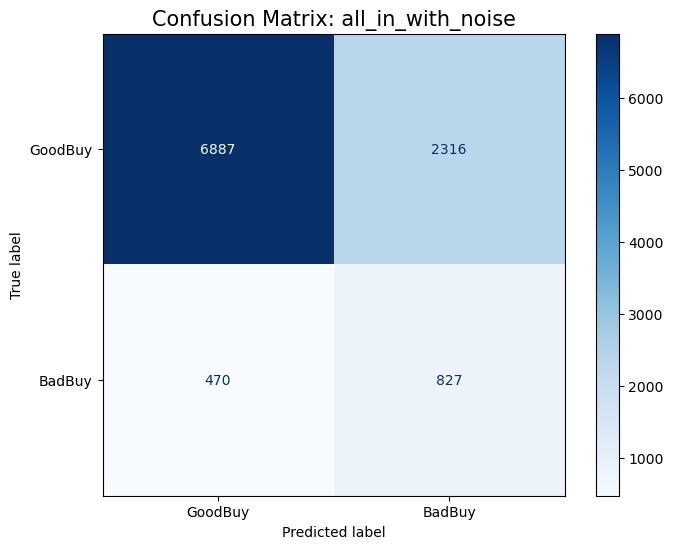

------------------------------
Korrekt als BadBuy erkannt (TP): 827
Übersehene BadBuys (FN):         470  <-- Das kostet Geld!
Fehlalarme (FP):                 2316  <-- Verpasste Deals!
------------------------------


In [22]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Vorhersage generieren
y_pred = pipeline.predict(X_val_final)

# 2. Der detaillierte Classification Report
# Zeigt Precision, Recall und F1 für BEIDE Klassen (0=Good, 1=BadBuy)
print("\n" + "="*60)
print(f"SUMMARY REPORT: {target_set}")
print("="*60)
print(classification_report(y_val, y_pred, target_names=['GoodBuy (0)', 'BadBuy (1)']))

# 3. Die Confusion Matrix (Visualisierung)
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['GoodBuy', 'BadBuy'])

# Styling der Matrix
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title(f'Confusion Matrix: {target_set}', fontsize=15)
plt.grid(False)
plt.show()

# 4. Quick-Check für den Tracker (Zusammenfassung)
tn, fp, fn, tp = cm.ravel()
print("-" * 30)
print(f"Korrekt als BadBuy erkannt (TP): {tp}")
print(f"Übersehene BadBuys (FN):         {fn}  <-- Das kostet Geld!")
print(f"Fehlalarme (FP):                 {fp}  <-- Verpasste Deals!")
print("-" * 30)



In [ ]:
BEster Lassoo 402

In [5]:
# 1. DATEN-AUSWAHL (Exakt 'all_in_with_noise' aus deinem Katalog)
target_set = "all_in_with_noise"
current_features = [f for f in features_catalog[target_set] if f in X_train.columns]

X_train_402 = X_train[current_features].copy()
X_val_402   = X_val[current_features].copy()

# 2. IDENTIFIZIERUNG DER SPALTENTYPEN
# Wir trennen nur nach Numerisch und Kategorisch, wie im Original-Run
num_cols = X_train_402.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_402.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. DER SIMPLE PREPROCESSOR (Keine manuelle PCA!)
# Das Lasso übernimmt hier die Selektion der Features
preprocessor_402 = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
], remainder='drop')

# 4. DIE PIPELINE (Mit liblinear für Lasso-Support)
pipeline_402 = Pipeline([
    ('pre', preprocessor_402),
    ('model', LogisticRegression(
        penalty='l1',           # Lasso
        solver='liblinear',     # Schnell & stabil für diesen Run
        class_weight='balanced', 
        C=1.0,                  # Standard-Regularisierung
        random_state=42,
        max_iter=3000
    ))
])

# 5. TRAINING
print(f"🚀 Starte Rekonstruktion von Run 402 ({target_set})...")
pipeline_402.fit(X_train_402, y_train)

# 6. EVALUIERUNG
y_pred = pipeline_402.predict(X_val_402)
f1 = f1_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
pre = precision_score(y_val, y_pred)

# 7. TRACKER UPDATE
tracker.add_entry(
    model_name="reconstructed_402_lasso_all_in",
    model_obj=pipeline_402,
    features_name="All-In Noise Lasso (Simple OHE/Scale)",
    features_list=current_features,
    y_true=y_val,
    y_pred=y_pred
)

print(f"✅ Ergebnis: F1: {f1:.4f} (Ziel war 0.3801) | Recall: {rec:.4f} | Precision: {pre:.4f}")

🚀 Starte Rekonstruktion von Run 402 (all_in_with_noise)...
💾 Modell-Datei erstellt: ../data/04_models/export/430_reconstructed_402_lasso_all_in.joblib
ID 430: F1=0.3668 -> ✅ ÜBER 0.30 & GESPEICHERT
✅ Ergebnis: F1: 0.3668 (Ziel war 0.3801) | Recall: 0.6060 | Precision: 0.2630



════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 402 | Name: log_reg_lasso_all_in_with_noise
════════════════════════════════════════════════════════════
   • Features:     (Konnte Namen nicht auslesen)
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.94      0.77      0.84      9203
     Bad (1)       0.27      0.62      0.38      1297

    accuracy                           0.75     10500
   macro avg       0.60      0.70      0.61     10500
weighted avg       0.85      0.75      0.79     10500

❌ Ein Fehler ist aufgetreten: name 'plt' is not defined


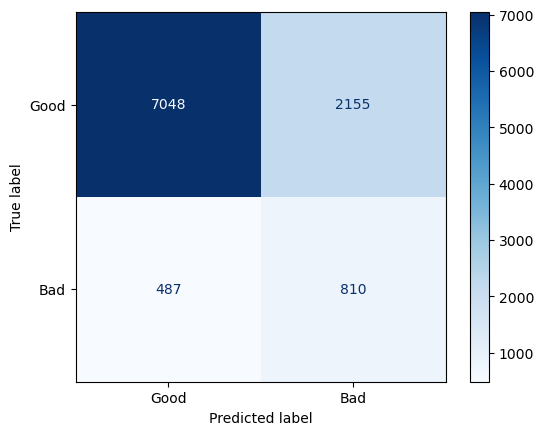

In [6]:
models.inspect_run_full(402, X_val, y_val, tracker)


════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 420 | Name: reconstructed_402_lasso_all_in
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          LogisticRegression
   • Penalty:      l1
   • Solver:       liblinear
   • C (Regul.):   1.0
   • Class Weight: balanced
   • Max Iter:     3000
   • Features:     27 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.93      0.76      0.84      9203
     Bad (1)       0.26      0.61      0.37      1297

    accuracy                           0.74     10500
   macro avg       0.60      0.68      0.60     10500
weighted avg       0.85      0.74      0.78     10500

❌ Ein Fehler ist aufgetreten: name 'plt' is not defined


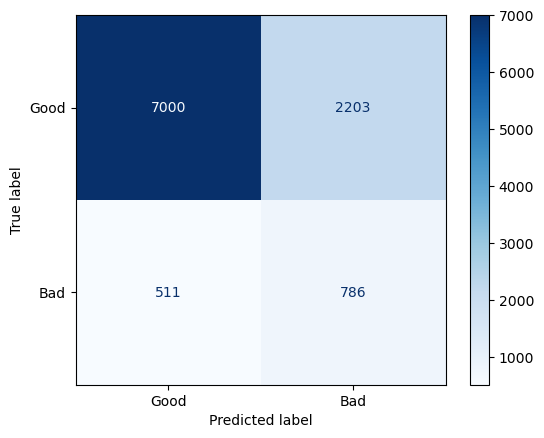


════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 419 | Name: logreg_lasso_full_buffet
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          LogisticRegression
   • Penalty:      l1
   • Solver:       liblinear
   • C (Regul.):   0.8
   • Class Weight: balanced
   • Max Iter:     3000
   • Features:     41 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.94      0.75      0.83      9203
     Bad (1)       0.26      0.64      0.37      1297

    accuracy                           0.73     10500
   macro avg       0.60      0.69      0.60     10500
weighted avg       0.85      0.73      0.78     10500

❌ Ein Fehler ist aufgetreten: name 'plt' is not defined


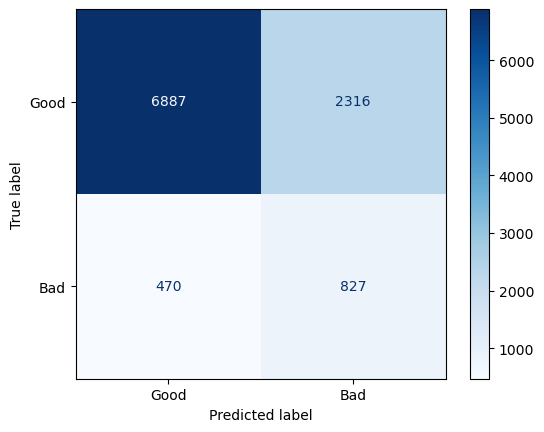

In [23]:

models.inspect_run_full(419, X_val, y_val, tracker)


════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 422 | Name: reconstructed_402_lasso_all_in
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          LogisticRegression
   • Penalty:      l1
   • Solver:       liblinear
   • C (Regul.):   1.0
   • Class Weight: balanced
   • Max Iter:     3000
   • Features:     27 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.93      0.76      0.84      9203
     Bad (1)       0.26      0.61      0.37      1297

    accuracy                           0.74     10500
   macro avg       0.60      0.68      0.60     10500
weighted avg       0.85      0.74      0.78     10500

❌ Ein Fehler ist aufgetreten: name 'plt' is not defined


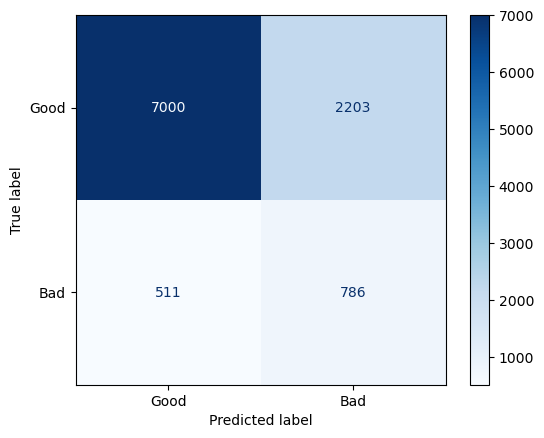

In [26]:

models.inspect_run_full(422, X_val, y_val, tracker)

In [27]:
# CrossValidation zum Testen 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('pca_prices', ...), ('pca_history', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [28]:
from sklearn.model_selection import cross_validate

# 1. Wir nehmen deine exakte Pipeline (id 419/420)
# Falls du sie gerade nicht in einer Variablen hast, hier kurz der Nachbau:
cv_pipeline = pipeline  # Nutze die Pipeline, die du gerade gefittet hast

print(f"🔄 Starte 5-Fold Cross-Validation für das Lasso-Modell...")

# 2. Durchführung der CV
# Wir nutzen cv=5, das heißt 5 Durchläufe auf jeweils 20% Testdaten
cv_results = cross_validate(
    cv_pipeline, 
    X_train_final, 
    y_train, 
    cv=5, 
    scoring=['f1', 'recall', 'precision'],
    n_jobs=-1, # Nutzt alle Kerne für Speed
    verbose=1
)

# 3. Ergebnisse schön aufbereiten
f1_scores = cv_results['test_f1']
recall_scores = cv_results['test_recall']

print("\n" + "═"*60)
print("📊 CROSS-VALIDATION ERGEBNISSE (Lasso L1, C=0.8)")
print("═"*60)
print(f"   • F1-Score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
print(f"   • Recall:   {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
print(f"   • Precision:{cv_results['test_precision'].mean():.4f}")
print("-" * 60)
print(f"   Einzelne F1-Werte: {np.round(f1_scores, 4).tolist()}")
print("═"*60)

🔄 Starte 5-Fold Cross-Validation für das Lasso-Modell...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent val


════════════════════════════════════════════════════════════
📊 CROSS-VALIDATION ERGEBNISSE (Lasso L1, C=0.8)
════════════════════════════════════════════════════════════
   • F1-Score: 0.3637 (+/- 0.0085)
   • Recall:   0.6086 (+/- 0.0220)
   • Precision:0.2594
------------------------------------------------------------
   Einzelne F1-Werte: [0.3616, 0.3648, 0.3683, 0.3747, 0.349]
════════════════════════════════════════════════════════════


[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed:  4.3min finished


🔎 Suche nach den perfekten Parametern...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/Users/kaywiegand/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio

KeyboardInterrupt: 

In [6]:
pipeline = pipeline_402
features = current_features

# Grid Search mit Bestem Lasso = neuer Bester
* 🔎 Suche läuft (Kombinationen werden durchgerechnet)...
* Fitting 3 folds for each of 7 candidates, totalling 21 fits
* 💾 Modell-Datei erstellt: ../data/04_models/export/429_logreg_lasso_grid_best.joblib
* ID 429: F1=0.3814 -> 🏆 NEUER BESTWERT & GESPEICHERT

🔎 Suche läuft (Kombinationen werden durchgerechnet)...
Fitting 3 folds for each of 7 candidates, totalling 21 fits
💾 Modell-Datei erstellt: ../data/04_models/export/429_logreg_lasso_grid_best.joblib
ID 429: F1=0.3814 -> 🏆 NEUER BESTWERT & GESPEICHERT

✅ Erfolgreich! Der Champion wurde als ID 429 im Tracker verewigt.

════════════════════════════════════════════════════════════
🧐 AUTOMATISCHE INSPEKTION VON RUN 429
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 429 | Name: logreg_lasso_grid_best
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          LogisticRegression
   • Penalty:      l1
   • Solver:       liblinear
   • C (Regul.):   0.1
   • Class Weight: balanced
   • Max Iter:     3000
   • Features:     41 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-scor

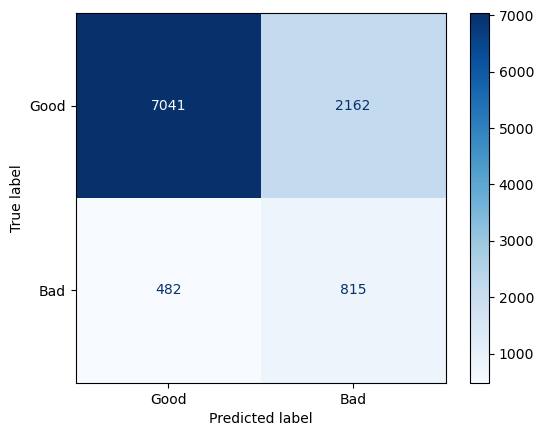

In [18]:

# 1. Das Such-Gitter (Hier kannst du Cs hinzufügen oder ändern)
param_grid = {
    'model__C': [0.1, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0],
    'model__solver': ['liblinear']
}

# 2. GridSearch aufsetzen
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

# 3. Suche starten
print("🔎 Suche läuft (Kombinationen werden durchgerechnet)...")
grid.fit(X_train, y_train)

# 4. Bestes Modell für die Validierung nutzen
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_val)

# 5. AB IN DEN TRACKER
new_id = tracker.add_entry(
    model_name="logreg_lasso_grid_best",
    model_obj=best_model, 
    features_name="Hybrid Buffet GridSearch",
    features_list=features,
    y_true=y_val,
    y_pred=y_pred_best,
    description=f"🏆 Gewinner: {grid.best_params_} | CV-F1: {grid.best_score_:.4f}"
)

print(f"\n✅ Erfolgreich! Der Champion wurde als ID {new_id} im Tracker verewigt.")

# 6. DER AUTOMATISCHE CHECK-UP (aus deiner models.py)
# Jetzt rufen wir deine neue Funktion direkt mit der frisch erzeugten ID auf
print("\n" + "═"*60)
print(f"🧐 AUTOMATISCHE INSPEKTION VON RUN {new_id}")
print("═"*60)

models.inspect_run_full(new_id, X_val, y_val, tracker)

In [19]:
# 1. Ergebnisse in ein DataFrame umwandeln
cv_results_df = pd.DataFrame(grid.cv_results_)

# 2. Die wichtigsten Spalten auswählen (damit es übersichtlich bleibt)
# Wir filtern auf Parameter, den mittleren Test-Score und die Zeit
score_cols = [col for col in cv_results_df.columns if 'param_' in col] + \
             ['mean_test_score', 'std_test_score', 'mean_fit_time', 'rank_test_score']

# 3. Sortieren nach Rang (Platz 1 oben)
display(cv_results_df[score_cols].sort_values(by='rank_test_score'))

,param_model__C,param_model__solver,mean_test_score,std_test_score,mean_fit_time,rank_test_score
0,0.1000,liblinear,0.3718,0.0024,15.7346,1
1,0.5000,liblinear,0.3633,0.0022,24.6785,2
2,0.8000,liblinear,0.3608,0.0024,30.2637,3
3,1.0000,liblinear,0.3582,0.0038,26.9915,4
4,1.2000,liblinear,0.3578,0.0048,28.5956,5
5,1.5000,liblinear,0.3556,0.0064,23.1827,6
6,2.0000,liblinear,0.3530,0.0071,18.9327,7


🔎 Suche läuft (Kombinationen werden durchgerechnet)...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
💾 Modell-Datei erstellt: ../data/04_models/export/431_logreg_lasso_grid_best.joblib
ID 431: F1=0.3814 -> ✅ ÜBER 0.30 & GESPEICHERT

✅ Erfolgreich! Der Champion wurde als ID 431 im Tracker verewigt.

════════════════════════════════════════════════════════════
🧐 AUTOMATISCHE INSPEKTION VON RUN 431
════════════════════════════════════════════════════════════

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 431 | Name: logreg_lasso_grid_best
════════════════════════════════════════════════════════════
⚙️  MODELL-EINSTELLUNGEN:
   • Typ:          LogisticRegression
   • Penalty:      l1
   • Solver:       liblinear
   • C (Regul.):   0.1
   • Class Weight: balanced
   • Max Iter:     500
   • Features:     41 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   su

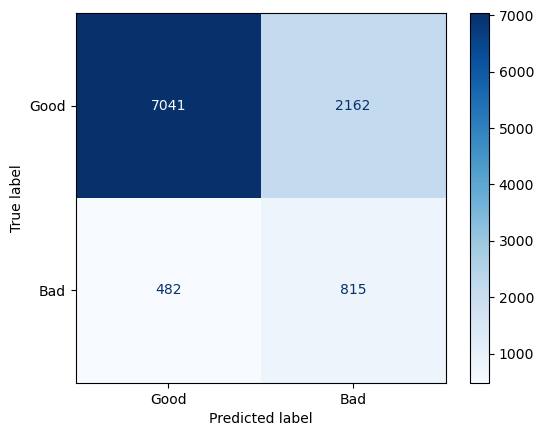

In [7]:
from sklearn.model_selection import GridSearchCV

# 1. Das Such-Gitter (Hier kannst du Cs hinzufügen oder ändern)
param_grid = {
    'model__C': [0.001, 0.007, 0.1, 0.3, 1.0, 10.0],
    'model__solver': ['liblinear'],
    'model__max_iter': [500]
}

# 2. GridSearch aufsetzen
grid = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=3, 
    scoring='f1', 
    n_jobs=-1, 
    verbose=1
)

# 3. Suche starten
print("🔎 Suche läuft (Kombinationen werden durchgerechnet)...")
grid.fit(X_train, y_train)

# 4. Bestes Modell für die Validierung nutzen
best_model = grid.best_estimator_
y_pred_best = best_model.predict(X_val)

# 5. AB IN DEN TRACKER
new_id = tracker.add_entry(
    model_name="logreg_lasso_grid_best",
    model_obj=best_model, 
    features_name="Hybrid Buffet GridSearch",
    features_list=features,
    y_true=y_val,
    y_pred=y_pred_best,
    description=f"🏆 Gewinner: {grid.best_params_} | CV-F1: {grid.best_score_:.4f}"
)

print(f"\n✅ Erfolgreich! Der Champion wurde als ID {new_id} im Tracker verewigt.")

# 6. DER AUTOMATISCHE CHECK-UP (aus deiner models.py)
# Jetzt rufen wir deine neue Funktion direkt mit der frisch erzeugten ID auf
print("\n" + "═"*60)
print(f"🧐 AUTOMATISCHE INSPEKTION VON RUN {new_id}")
print("═"*60)

models.inspect_run_full(new_id, X_val, y_val, tracker)

# Best Lasso - Pipeline


| Kategorie            | Wert |
|----------------------|------|
| Run ID               | 432 |
| Modellname           | reconstructed_402_lasso_all_in |
| Modelltyp            | Logistic Regression (L1 / Lasso) |
| Solver               | liblinear |
| Features gesamt      | 27 |
| Datensatz Größe      | 10,500 |
| Klasse 0 (Good)      | 9,203 |
| Klasse 1 (Bad)       | 1,297 |
| Accuracy             | 0.74 |
| F1-Score (Bad)       | 0.3668 |
| Recall (Bad)         | 0.6060 |
| Precision (Bad)      | 0.2630 |
| Macro Avg F1         | 0.60 |
| Weighted Avg F1      | 0.78 |
| Modell gespeichert   | ✅ |


| Klasse     | Precision | Recall | F1-Score | Support |
|------------|----------|--------|----------|---------|
| Good (0)   | 0.93     | 0.76   | 0.84     | 9203    |
| Bad (1)    | 0.26     | 0.61   | 0.37     | 1297    |


| #  | Feature |
|----|--------|
| 1  | VehicleAge |
| 2  | VehOdo |
| 3  | VehBCost |
| 4  | WarrantyCost |
| 5  | MMRAcquisitionAuctionAveragePrice |
| 6  | MMRCurrentAuctionAveragePrice |
| 7  | feat_miles_per_year |
| 8  | feat_price_ratio |
| 9  | feat_price_diff |
| 10 | feat_market_trend |
| 11 | feat_warranty_ratio |
| 12 | feat_age_group |
| 13 | feat_odo_risk |
| 14 | feat_price_cat |
| 15 | feat_warranty_peak |
| 16 | Make |
| 17 | Model |
| 18 | Trim |
| 19 | SubModel |
| 20 | VNZIP1 |
| 21 | Auction |
| 22 | WheelType |
| 23 | Color |
| 24 | Transmission |
| 25 | Nationality |
| 26 | Size |
| 27 | IsOnlineSale |


# 'VehOdo' bzw. das Alter 'VehicleAge'

In [4]:
# Feature-Subset
target_set = "log_reg_set_01"

cols = [c for c in features_catalog[target_set] if c in X_train.columns]

# Split + Typen
Xtr, Xva = X_train[cols], X_val[cols]
num = Xtr.select_dtypes(include="number").columns
cat = Xtr.select_dtypes(exclude="number").columns

# Pipeline
pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)
    ])),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

# Fit + Eval
pipe.fit(Xtr, y_train)
y_pred = pipe.predict(Xva)

f1  = f1_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
pre = precision_score(y_val, y_pred)

xxx = tracker.add_entry(
    "reconstructed_402_lasso_all_in",
    pipe,
    "All-In Noise Lasso (Simple OHE/Scale)",
    cols,
    y_val,
    y_pred
)

print(f"F1: {f1:.4f} | Recall: {rec:.4f} | Precision: {pre:.4f}")

models.inspect_run_full(xxx, X_val, y_val, tracker)

ID 446: F1=0.2978 -> 🔈 Nur CSV (F1 zu niedrig)
F1: 0.2978 | Recall: 0.6299 | Precision: 0.1950
❌ Datei nicht gefunden: ../data/04_models/No


In [ ]:
# Feature-Subset
target_set = "all_in_with_noise"
cols = [c for c in features_catalog[target_set] if c in X_train.columns]

# Split + Typen
Xtr, Xva = X_train[cols], X_val[cols]
num = Xtr.select_dtypes(include="number").columns
cat = Xtr.select_dtypes(exclude="number").columns

# Pipeline
pipe = Pipeline([
    ("pre", ColumnTransformer([
        ("num", StandardScaler(), num),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat)
    ])),
    ("clf", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

# Fit + Eval
pipe.fit(Xtr, y_train)
y_pred = pipe.predict(Xva)

f1  = f1_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
pre = precision_score(y_val, y_pred)

tracker.add_entry(
    "reconstructed_402_lasso_all_in",
    pipe,
    "All-In Noise Lasso (Simple OHE/Scale)",
    cols,
    y_val,
    y_pred
)

print(f"F1: {f1:.4f} | Recall: {rec:.4f} | Precision: {pre:.4f}")


════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 432 | Name: reconstructed_402_lasso_all_in
════════════════════════════════════════════════════════════
   • Features:     27 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.93      0.76      0.84      9203
     Bad (1)       0.26      0.61      0.37      1297

    accuracy                           0.74     10500
   macro avg       0.60      0.68      0.60     10500
weighted avg       0.85      0.74      0.78     10500



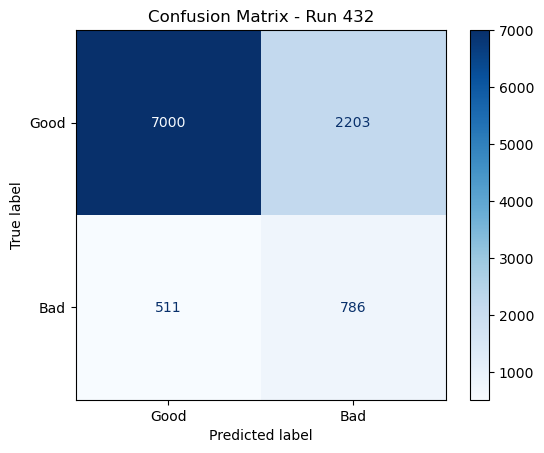

In [4]:
models.inspect_run_full(432, X_val, y_val, tracker)

In [19]:
cols

['VehicleAge',
 'VehOdo',
 'VehBCost',
 'WarrantyCost',
 'MMRAcquisitionAuctionAveragePrice',
 'MMRCurrentAuctionAveragePrice',
 'feat_miles_per_year',
 'feat_price_ratio',
 'feat_price_diff',
 'feat_market_trend',
 'feat_warranty_ratio',
 'feat_age_group',
 'feat_odo_risk',
 'feat_price_cat',
 'feat_warranty_peak',
 'Make',
 'Model',
 'Trim',
 'SubModel',
 'VNZIP1',
 'Auction',
 'WheelType',
 'Color',
 'Transmission',
 'Nationality',
 'Size',
 'IsOnlineSale']

In [21]:
feature_names = pipe.named_steps["pre"].get_feature_names_out()

coefs = pipe.named_steps["clf"].coef_[0]

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs,
    "abs_importance": abs(coefs)
}).sort_values("abs_importance", ascending=False)

feat_imp.head(20)

,feature,coefficient,abs_importance
461,cat__Model_GX470 4WD,5.0970,5.0970
760,cat__Model_RX400H AWD,4.5243,4.5243
1444,cat__SubModel_4D SPORT UTILITY HYBRID LIMITED,4.1941,4.1941
83,cat__Model_4 RUNNER 2WD V6,3.7105,3.7105
2021,cat__VNZIP1_85018,-3.4763,3.4763
556,cat__Model_MALIBU HYBRID,3.4210,3.4210
2058,cat__WheelType_Unknown,3.4012,3.4012
735,cat__Model_RELAY AWD V6,3.1564,3.1564
603,cat__Model_MONTANA 3.4L V6 SFI,-3.0177,3.0177
1332,cat__SubModel_4D SEDAN GXE,-3.0011,3.0011


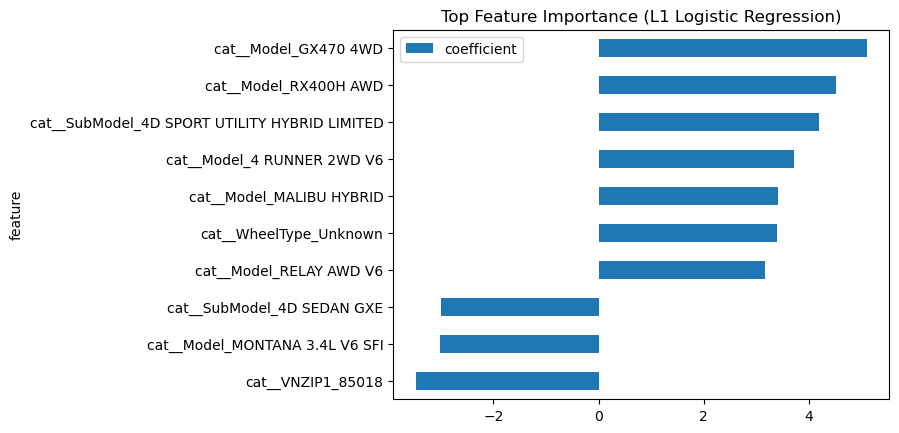

In [25]:
import matplotlib.pyplot as plt

feat_imp.head(10).sort_values("coefficient").plot(
    x="feature",
    y="coefficient",
    kind="barh"
)

plt.title("Top Feature Importance (L1 Logistic Regression)")
plt.show()

In [9]:

y_proba = pipe.predict_proba(X_val[cols])[:, 1]

thresholds = np.linspace(0.0, 1.0, 101)

results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    
    results.append({
        "threshold": t,
        "f1": f1_score(y_val, y_pred_t),
        "precision": precision_score(y_val, y_pred_t),
        "recall": recall_score(y_val, y_pred_t)
    })

df_thresh = pd.DataFrame(results)

# bester Threshold
best = df_thresh.loc[df_thresh["f1"].idxmax()]
best

threshold   0.7200
f1          0.4064
precision   0.4967
recall      0.3439
Name: 72, dtype: float64

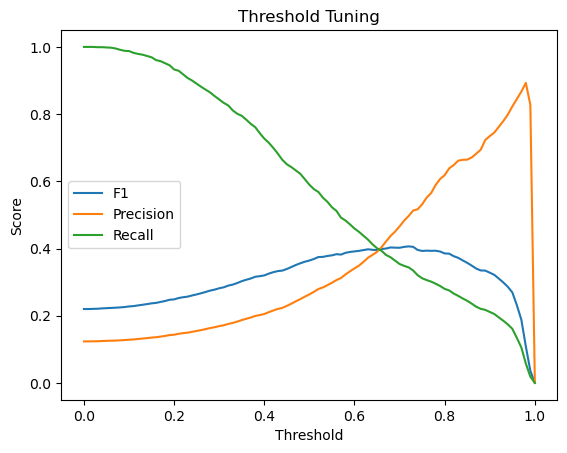

In [10]:
plt.plot(df_thresh["threshold"], df_thresh["f1"], label="F1")
plt.plot(df_thresh["threshold"], df_thresh["precision"], label="Precision")
plt.plot(df_thresh["threshold"], df_thresh["recall"], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.title("Threshold Tuning")
plt.show()

In [11]:
best_t = best["threshold"]

y_pred_opt = (y_proba >= best_t).astype(int)

print("Optimal Threshold:", best_t)
print("F1:", f1_score(y_val, y_pred_opt))
print("Recall:", recall_score(y_val, y_pred_opt))
print("Precision:", precision_score(y_val, y_pred_opt))

Optimal Threshold: 0.72
F1: 0.40637813211845103
Recall: 0.3438704703161141
Precision: 0.49665924276169265


In [12]:
tracker.add_entry(
    model_name=f"reconstructed_402_lasso_thresh_{best_t:.2f}",
    model_obj=pipe,
    features_name="All-In Lasso + Threshold",
    features_list=cols,
    y_true=y_val,
    y_pred=y_pred_opt
)

💾 Modell-Datei erstellt: ../data/04_models/export/438_reconstructed_402_lasso_thresh_0.72.joblib
ID 438: F1=0.4064 -> 🏆 NEUER BESTWERT & GESPEICHERT


438

Typischer realistischer Zielkonflikt:
✅ Recall hoch halten (möglichst viele „Bad“ finden)
❗ Precision nicht komplett zerstören
👉 Also z. B.:
„Maximiere Recall, unter der Bedingung, dass Precision ≥ 0.25 bleibt“


In [13]:
y_proba = pipe.predict_proba(X_val[cols])[:, 1]


In [14]:
# Loop Treshold

for i in range(10):
    df_valid = df_thresh[df_thresh["precision"] >= 0.075*i]
    best = df_valid.loc[df_valid["recall"].idxmax()]
    print()
    print(best)


threshold   0.0000
f1          0.2199
precision   0.1235
recall      1.0000
Name: 0, dtype: float64

threshold   0.0000
f1          0.2199
precision   0.1235
recall      1.0000
Name: 0, dtype: float64

threshold   0.2400
f1          0.2603
precision   0.1522
recall      0.8998
Name: 24, dtype: float64

threshold   0.4500
f1          0.3392
precision   0.2293
recall      0.6507
Name: 45, dtype: float64

threshold   0.5600
f1          0.3832
precision   0.3061
recall      0.5120
Name: 56, dtype: float64

threshold   0.6400
f1          0.3961
precision   0.3811
recall      0.4125
Name: 64, dtype: float64

threshold   0.6900
f1          0.4026
precision   0.4504
recall      0.3639
Name: 69, dtype: float64

threshold   0.7500
f1          0.3928
precision   0.5316
recall      0.3115
Name: 75, dtype: float64

threshold   0.7900
f1          0.3910
precision   0.6071
recall      0.2884
Name: 79, dtype: float64

threshold   0.8700
f1          0.3403
precision   0.6821
recall      0.2267
Name: 8

In [15]:

fbeta_score(y_val, y_pred, beta=2)

0.48061636296930416

In [16]:
# Crossvalidation für besten Treshold

def find_best_threshold(y_true, y_proba, beta=2):
    thresholds = np.linspace(0, 1, 101)
    scores = [
        fbeta_score(y_true, (y_proba >= t), beta=beta)
        for t in thresholds
    ]
    best_t = thresholds[np.argmax(scores)]
    return best_t

kf = StratifiedKFold(n_splits=5)
thresholds = []

for train_idx, val_idx in kf.split(X_train[cols], y_train):
    
    X_tr, X_va = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_va = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    pipe.fit(X_tr, y_tr)
    
    y_proba = pipe.predict_proba(X_va)[:, 1]
    
    t = find_best_threshold(y_va, y_proba, beta=2)
    thresholds.append(t)

best_t = np.mean(thresholds)

print(best_t)

0.392


# Zusammenfassung


### **"Clean & Lean" Baseline-Modell**

* Möglichst einfaches und schnelles Modell: **Logistische Regression**  
* Für eine möglichst treffsichere Vorherase nur die "vielversprechendsten" Features :
  * 8, um verschiednen Aspekte abzudecken und trotzdem kein Overfitting zu riskieren  
  * VehicleAge & VehOdo liefern das primäre Verschleißrisiko / Zusstand  
  * VehBCost & MMR-Anker für den finanziellen Aspekt / Ökonomie  
  * miles_per_year & price_ratio als Relative-Features Relationen
  * Auction & Make für die Herkunft
 
### Erkenntnis / Interpretation
Der „Clean & Lean“ Baseline-Check
Unsere Baseline ist das wissenschaftliche Nullinstrument. Sie zeigt, was mit minimalem Aufwand (8 Features) und maximaler Transparenz möglich ist:

* Strategie: Fokus auf Signaldichte statt Datenmüll. Wir nutzen nur die 8 „Killer-Features“ (Alter, KM, Preis-Anomalien), um Multikollinearität und Rauschen zu vermeiden.  
* **Recall (0,63)** – Der Risikofilter: Wir identifizieren bereits 63 % aller Problemfahrzeuge. Das Modell agiert als Sicherheitsnetz, das fast zwei Drittel des Risikos abfängt.  
* **Precision (0,19)** – Die Baustelle: Aktuell ist das Modell sehr „pessimistisch“. Von 100 Warnungen sind nur 19 echte Treffer. Hier liegt unser größtes Optimierungspotenzial für morgen.  
* **F1-Score (0,29)** – Die Startlinie: Wir stehen unmittelbar vor der magischen 0,30-Grenze. Dieser Wert ist unser Benchmark, den jedes komplexere Modell ab jetzt schlagen muss.  



## Bestes Logistische Regression Lasso

* F1 verbessert auf **~0.36–0.41**
* Einfaches Model 
* automatische Feature-Selektion
* reduziert Overfitting trotz vieler Features

* threshold   0.4800
* **f1          0.3604**
* **precision   0.2507**
* **recall      0.6407**


| Szenario            | Threshold | F1-Score | Precision | Recall | Interpretation |
|--------------------|----------|----------|-----------|--------|----------------|
| 🔺 Zu hoch         | 0.66     | 0.4014   | 0.4178    | 0.3863 | Sehr konservativ: wenige Fehlalarme (hohe Precision), aber viele Montagsautos werden übersehen (niedriger Recall) |
| ⚖️ Mittel (Default)| 0.50*    | ~0.36    | ~0.26     | ~0.61  | Klassischer Kompromiss: brauchbarer Recall, aber noch viele Fehlalarme |
| 🔻 Niedriger       | 0.48     | 0.3604   | 0.2507    | 0.6407 | Aggressiv: viele Montagsautos erkannt (hoher Recall), aber viele gute Autos fälschlich ausgeschlossen (niedrige Precision) |


* Der größte Performance-Gewinn kam nicht durch ein komplexeres Modell, sondern durch bessere Nutzung der Modell-Outputs (Threshold)

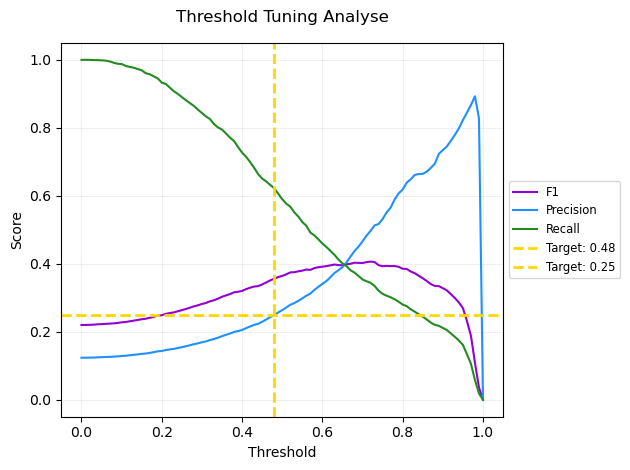

In [17]:
import matplotlib.pyplot as plt

plt.plot(df_thresh["threshold"], df_thresh["f1"], label="F1", color="darkviolet") # Violett
plt.plot(df_thresh["threshold"], df_thresh["precision"], label="Precision", color="dodgerblue") # Blau
plt.plot(df_thresh["threshold"], df_thresh["recall"], label="Recall", color="forestgreen") # Grün

plt.axvline(x=0.48, color='gold', linestyle='--', linewidth=2, label='Target: 0.48')
plt.axhline(y=0.25, color='gold', linestyle='--', linewidth=2, label='Target: 0.25')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning Analyse", pad=15)

plt.legend(fontsize='small', loc='center left', bbox_to_anchor=(1, 0.5))

plt.grid(True, alpha=0.2)
plt.tight_layout() # Wichtig, damit die Legende nicht abgeschnitten wird

plt.show()

In [18]:
df_valid = df_thresh[df_thresh["precision"] >= 0.25]

best = df_valid.loc[df_valid["recall"].idxmax()]
best

threshold   0.4900
f1          0.3608
precision   0.2569
recall      0.6060
Name: 49, dtype: float64

💾 Modell-Datei erstellt: ../data/04_models/export/439_Log-Reg-Lasso-432_all_in_with_noise.joblib
ID 439: F1=0.3562 -> ✅ ÜBER 0.30 & GESPEICHERT

════════════════════════════════════════════════════════════
🔍 ANALYSE RUN_ID: 439 | Name: Log-Reg-Lasso-432_all_in_with_noise
════════════════════════════════════════════════════════════
   • Features:     41 Spalten
------------------------------------------------------------
📊 PERFORMANCE REPORT:
              precision    recall  f1-score   support

    Good (0)       0.93      0.77      0.84      9203
     Bad (1)       0.26      0.59      0.36      1297

    accuracy                           0.75     10500
   macro avg       0.60      0.68      0.60     10500
weighted avg       0.85      0.75      0.78     10500



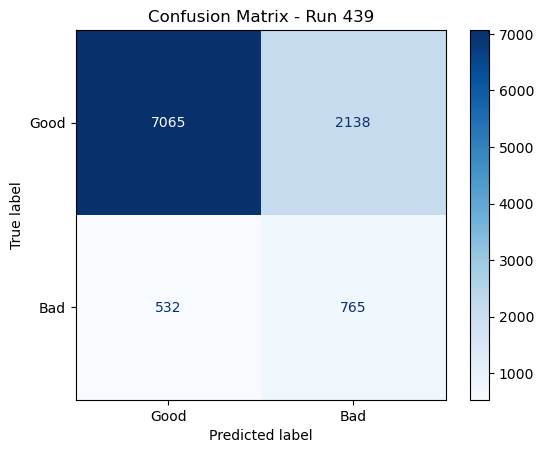

In [19]:


target_set = "all_in_with_noise"
cols = [c for c in features_catalog[target_set] if c in X_train.columns]

y_pred_proba = pipe.predict_proba(X_val[cols])[:, 1]
threshold = 0.48
y_pred_custom = (y_pred_proba >= threshold).astype(int)

idx = tracker.add_entry(
    model_name=f"Log-Reg-Lasso-432_all_in_with_noise",
    model_obj=pipe,
    features_name="All-In Lasso + Threshold",
    features_list=cols,
    y_true=y_val,
    y_pred=y_pred_custom
)

models.inspect_run_full(idx, X_val, y_val, tracker)
